# 01 — Probability Foundations & Bayes' Theorem

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §6.1–6.4, pp.172–186 (Construction of a Probability Space, Discrete and Continuous Probabilities, Sum Rule/Product Rule/Bayes' Theorem, Summary Statistics and Independence)

Part of the Statistics subchapter of the 6-month ML Engineer prep plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## The building blocks: joint, marginal, conditional

- **Joint probability** `P(A, B)` — the probability both `A` and `B` happen.
- **Marginal probability** `P(A)` — the probability of `A` alone, found by summing (or integrating) the joint over all values of `B`.
- **Conditional probability** `P(A|B)` — the probability of `A` *given that* `B` has happened: `P(A|B) = P(A,B) / P(B)`.

Two rules connect these:
- **Sum rule:** `P(A) = Σ_B P(A, B)` (marginalize out `B`)
- **Product rule:** `P(A, B) = P(A|B)·P(B) = P(B|A)·P(A)`

## Bayes' theorem — derived, not memorized

The product rule gives two ways to write the same joint probability: `P(A|B)P(B) = P(B|A)P(A)`. Divide both sides by `P(B)`:

```
P(A|B) = P(B|A) · P(A) / P(B)
```

That's Bayes' theorem. In the form you'll actually use it, with `H` for hypothesis and `E` for evidence:

```
P(H|E) = P(E|H) · P(H) / P(E)
       = likelihood × prior / evidence
       = posterior
```

## The classic worked example — and why it trips people up

A disease affects 1% of a population. A test is 99% sensitive (`P(+|disease)=0.99`) and 95% specific (`P(-|healthy)=0.95`). If someone tests positive, what's `P(disease | positive)`? Intuition says "almost certainly" — the real answer is much lower.

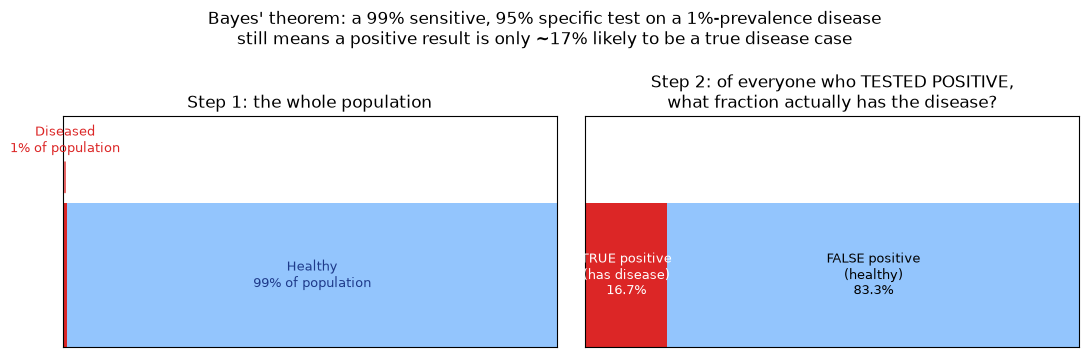

P(disease | positive) = 0.1667 ≈ 16.7%


In [2]:
def visualize_bayes_partition(savepath: Path = None):
    p_d = 0.01     # prevalence
    sens = 0.99    # P(+|disease)
    spec = 0.95    # P(-|healthy)
    fp_rate = 1 - spec

    p_disease, p_healthy = p_d, 1 - p_d
    tp = p_disease * sens
    fn = p_disease * (1 - sens)
    fp = p_healthy * fp_rate
    tn = p_healthy * spec
    p_pos = tp + fp
    posterior = tp / p_pos

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

    ax = axes[0]
    ax.add_patch(Rectangle((0, 0), p_disease, 1, facecolor="#dc2626"))
    ax.add_patch(Rectangle((p_disease, 0), p_healthy, 1, facecolor="#93c5fd"))
    ax.annotate(f"Diseased\n{p_disease*100:.0f}% of population", xy=(p_disease/2, 1.05),
                ha="center", fontsize=9, color="#dc2626",
                xytext=(p_disease/2, 1.35), arrowprops=dict(arrowstyle="-", color="#dc2626"))
    ax.text(p_disease + p_healthy/2, 0.5, f"Healthy\n{p_healthy*100:.0f}% of population",
            ha="center", va="center", fontsize=9, color="#1e3a8a")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.6)
    ax.set_yticks([]); ax.set_xticks([])
    ax.set_title("Step 1: the whole population")

    ax2 = axes[1]
    ax2.add_patch(Rectangle((0, 0), tp/p_pos, 1, facecolor="#dc2626"))
    ax2.add_patch(Rectangle((tp/p_pos, 0), fp/p_pos, 1, facecolor="#93c5fd"))
    ax2.text(tp/p_pos/2, 0.5, f"TRUE positive\n(has disease)\n{posterior*100:.1f}%",
             ha="center", va="center", fontsize=9, color="white")
    ax2.text(tp/p_pos + (fp/p_pos)/2, 0.5, f"FALSE positive\n(healthy)\n{(1-posterior)*100:.1f}%",
             ha="center", va="center", fontsize=9, color="black")
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.6)
    ax2.set_yticks([]); ax2.set_xticks([])
    ax2.set_title("Step 2: of everyone who TESTED POSITIVE,\nwhat fraction actually has the disease?")

    fig.suptitle("Bayes\' theorem: a 99% sensitive, 95% specific test on a 1%-prevalence disease\n"
                 f"still means a positive result is only ~{posterior*100:.0f}% likely to be a true disease case")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return posterior

posterior = visualize_bayes_partition(FIG_DIR / "bayes_partition.png")
print(f"P(disease | positive) = {posterior:.4f} ≈ {posterior*100:.1f}%")

The math: `P(D|+) = P(+|D)P(D) / P(+) = 0.99×0.01 / (0.99×0.01 + 0.05×0.99) ≈ 16.7%`.

Even with a highly accurate test, most positives are false positives — because the disease is rare (low prior), the small false-positive rate applied to the *much larger* healthy population still outnumbers the true positives from the *much smaller* diseased population. This "base rate" reasoning generalizes directly to ML: it's the same reason a classifier can have 99% accuracy and still be nearly useless on a highly imbalanced dataset (predicting "no fraud" always gets you 99%+ accuracy if fraud is rare) — precision, not accuracy, is what tells you whether a positive prediction is trustworthy, and precision has exactly this Bayes'-theorem structure (`TP / (TP + FP)`).

## Independence vs. zero correlation — a classic trap

Two variables are **independent** if knowing one tells you nothing about the other: `P(A,B) = P(A)P(B)`. They're **uncorrelated** if their (linear) correlation coefficient is zero. Independence implies zero correlation — but the reverse is *not* true, and interviewers love this gap.

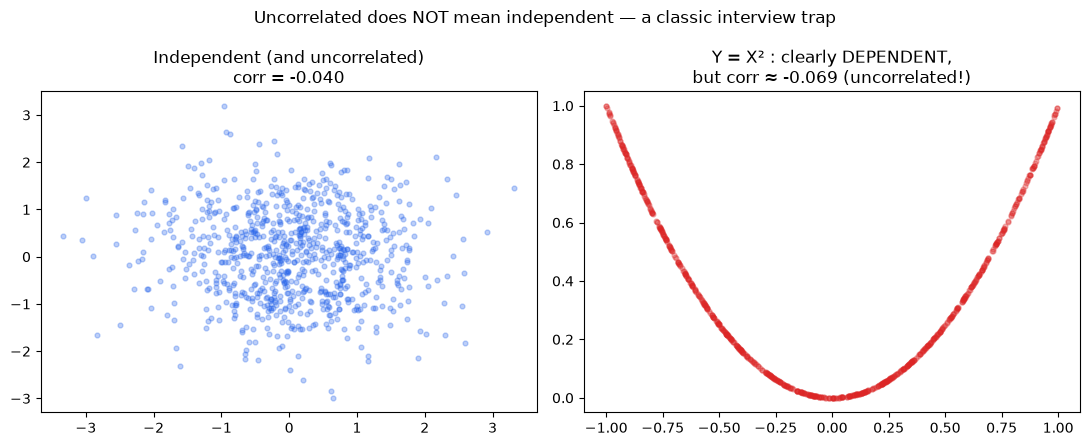

In [3]:
def visualize_independence_vs_correlation(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(3)
    n = 800

    x_indep = rng.normal(size=n)
    y_indep = rng.normal(size=n)
    corr_indep = np.corrcoef(x_indep, y_indep)[0, 1]

    x_dep = rng.uniform(-1, 1, size=n)
    y_dep = x_dep ** 2
    corr_dep = np.corrcoef(x_dep, y_dep)[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(x_indep, y_indep, alpha=0.3, s=12, color="#2563eb")
    axes[0].set_title(f"Independent (and uncorrelated)\ncorr = {corr_indep:.3f}")

    axes[1].scatter(x_dep, y_dep, alpha=0.3, s=12, color="#dc2626")
    axes[1].set_title(f"Y = X² : clearly DEPENDENT,\nbut corr ≈ {corr_dep:.3f} (uncorrelated!)")

    fig.suptitle("Uncorrelated does NOT mean independent — a classic interview trap")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_independence_vs_correlation(FIG_DIR / "independence_vs_correlation.png")

The right panel is completely deterministic — knowing `X` tells you `Y` *exactly* — yet the linear correlation is essentially zero, because correlation only measures *linear* association, and this relationship is symmetric/quadratic. This is exactly why feature engineering sometimes adds explicit non-linear transforms (`x²`, interaction terms) even when a raw feature shows no linear correlation with the target — the relationship can still be there, just not linear.

---

## Self-check before moving on

- [ ] I can derive Bayes' theorem from the product rule, not just recite it
- [ ] I can work the disease-testing example from scratch and explain intuitively why the answer is low
- [ ] I can connect this base-rate reasoning to precision on imbalanced classification datasets
- [ ] I can state the difference between independence and zero correlation, with an example

Next: `02-distributions-mle-map.ipynb` ⭐